# FL-IDS Preprocessing Visualization

This notebook turns the data pipeline into a teacher-facing walkthrough. It loads the saved CIC-IDS2017 artifacts, replays the preprocessing steps on a manageable sample for explanation, and visualizes the generated train/test/Non-IID outputs.

In [3]:
from pathlib import Path
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.configs.paths import RAW_DIR, PREPROCESSED_DIR, DATA_DIR
from src.components.data.data_preprocessor import (
    DROP_COLS,
    drop_unusable,
    impute,
    variance_filter,
    correlation_filter,
    encode_labels,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 90)

RAW_PATH = RAW_DIR / "cicids2017_raw.parquet"
PRE_PATH = PREPROCESSED_DIR / "cicids2017_preprocessed.parquet"
FEATURES_PATH = PREPROCESSED_DIR / "feature_cols.pkl"
LABEL_ENCODER_PATH = PREPROCESSED_DIR / "label_encoder.pkl"
SCALER_PATH = PREPROCESSED_DIR / "scaler.pkl"
TEST_PATH = PREPROCESSED_DIR / "test_set.npz"

required = [RAW_PATH, PRE_PATH, FEATURES_PATH, LABEL_ENCODER_PATH, SCALER_PATH, TEST_PATH]
missing = [str(p.relative_to(ROOT)) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Run the data pipeline first. Missing artifacts: " + ", ".join(missing))

## 1. Load Saved Pipeline Artifacts

The raw and preprocessed parquet files are the evidence that the pipeline already ran. The label encoder, feature list, scaler, test set, and client shards show the exact downstream objects used for training.

In [4]:
raw_df = pd.read_parquet(RAW_PATH)
pre_df = pd.read_parquet(PRE_PATH)

with open(FEATURES_PATH, "rb") as f:
    feature_cols = pickle.load(f)
with open(LABEL_ENCODER_PATH, "rb") as f:
    label_encoder = pickle.load(f)
with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)
test_data = np.load(TEST_PATH)
X_test, y_test = test_data["X"], test_data["y"]

summary = pd.DataFrame(
    [
        ["Raw dataframe", raw_df.shape[0], raw_df.shape[1], "Before preprocessing"],
        ["Preprocessed dataframe", pre_df.shape[0], pre_df.shape[1], "After drop/impute/filter/encode"],
        ["Selected feature matrix", pre_df.shape[0], len(feature_cols), "Features saved in feature_cols.pkl"],
        ["Scaled held-out test set", X_test.shape[0], X_test.shape[1], "80/20 stratified split, scaler fit on train only"],
        ["Client partition files", len(list(DATA_DIR.glob("client_*.npz"))), np.nan, "Saved Non-IID client shards"],
    ],
    columns=["Artifact", "Rows / Count", "Columns / Features", "Meaning"],
)
display(summary)
display(pd.DataFrame({"Encoded label": range(len(label_encoder.classes_)), "Original label": label_encoder.classes_}))

,Artifact,Rows / Count,Columns / Features,Meaning
0,Raw dataframe,2099971,89.0,Before preprocessing
1,Preprocessed dataframe,2099971,85.0,After drop/impute/filter/encode
2,Selected feature matrix,2099971,57.0,Features saved in feature_cols.pkl
3,Scaled held-out test set,419995,57.0,"80/20 stratified split, scaler fit on train only"
4,Client partition files,50,NaN,Saved Non-IID client shards


,Encoded label,Original label
0,0,BENIGN
1,1,Botnet
2,2,Botnet - Attempted
3,3,DDoS
4,4,DoS GoldenEye
5,5,DoS GoldenEye - Attempted
6,6,DoS Hulk
7,7,DoS Hulk - Attempted
8,8,DoS Slowhttptest
9,9,DoS Slowhttptest - Attempted


## 2. Replay Each Preprocessing Step

For speed, this section replays the same functions on a fixed sample. The saved artifacts above remain the full pipeline output used by the project.

,Step,Rows,Columns,Feature columns,NaN cells,Inf cells,Label classes,Note
0,Raw input,150000,89,88,0,0,25,Dataset sample before project preprocessing
1,1. Drop unusable,150000,85,84,0,0,25,"Drop ID/time columns, all-NaN columns, non-numeric columns except Label"
2,2. Impute,150000,85,84,0,0,25,"Replace Inf with NaN, then fill NaN by numeric column median"
3,3. Variance filter,150000,84,83,0,0,25,Remove constant features
4,4. Correlation filter,150000,57,56,0,0,25,Remove highly correlated features using Pearson |r| > 0.95
5,5. Label encode,150000,57,56,0,0,25,Convert attack names to integer class IDs


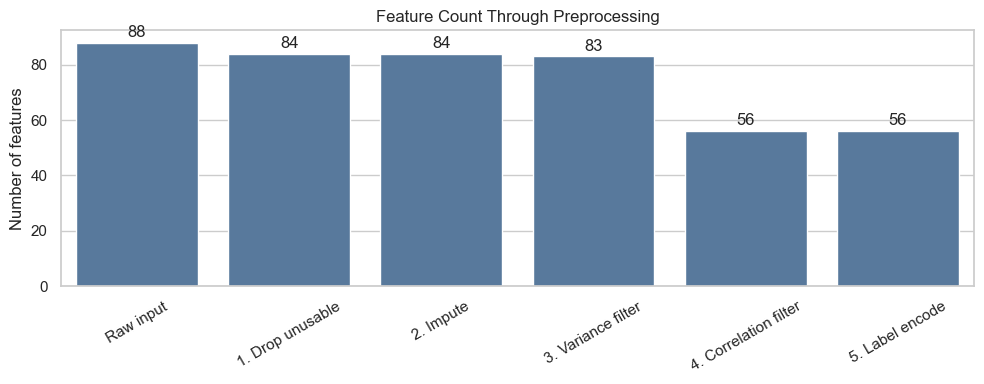

In [5]:
SAMPLE_ROWS = min(150_000, len(raw_df))
raw_work = raw_df.sample(SAMPLE_ROWS, random_state=42).copy() if len(raw_df) > SAMPLE_ROWS else raw_df.copy()

def numeric_inf_count(df):
    numeric = df.select_dtypes(include=[np.number])
    return int(np.isinf(numeric.to_numpy()).sum()) if not numeric.empty else 0

def make_record(name, df, note):
    feature_count = len([c for c in df.columns if c != "Label"])
    return {
        "Step": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Feature columns": feature_count,
        "NaN cells": int(df.isna().sum().sum()),
        "Inf cells": numeric_inf_count(df),
        "Label classes": df["Label"].nunique() if "Label" in df.columns else np.nan,
        "Note": note,
    }

records = [make_record("Raw input", raw_work, "Dataset sample before project preprocessing")]

after_drop = drop_unusable(raw_work.copy())
records.append(make_record("1. Drop unusable", after_drop, "Drop ID/time columns, all-NaN columns, non-numeric columns except Label"))

after_impute = impute(after_drop.copy())
records.append(make_record("2. Impute", after_impute, "Replace Inf with NaN, then fill NaN by numeric column median"))

start_features = [c for c in after_impute.columns if c != "Label"]
var_features = variance_filter(after_impute, start_features)
after_var = after_impute[var_features + ["Label"]].copy()
records.append(make_record("3. Variance filter", after_var, "Remove constant features"))

corr_features = correlation_filter(after_impute, var_features, threshold=0.95)
after_corr = after_impute[corr_features + ["Label"]].copy()
records.append(make_record("4. Correlation filter", after_corr, "Remove highly correlated features using Pearson |r| > 0.95"))

after_encoded, sample_encoder = encode_labels(after_corr.copy())
records.append(make_record("5. Label encode", after_encoded, "Convert attack names to integer class IDs"))

step_table = pd.DataFrame(records)
display(step_table)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=step_table, x="Step", y="Feature columns", ax=ax, color="#4C78A8")
ax.set_title("Feature Count Through Preprocessing")
ax.set_xlabel("")
ax.set_ylabel("Number of features")
ax.tick_params(axis="x", rotation=30)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)
plt.tight_layout()

In [6]:
all_nan_cols = raw_work.columns[raw_work.isna().all()].tolist()
non_numeric_dropped = [c for c in raw_work.columns if c != "Label" and c not in raw_work.select_dtypes(include=[np.number]).columns]
explicit_drop_cols = [c for c in DROP_COLS if c in raw_work.columns]
zero_variance_dropped = sorted(set(start_features) - set(var_features))
correlated_dropped = sorted(set(var_features) - set(corr_features))

removed = pd.DataFrame(
    [
        ["Configured ID/time drops", len(explicit_drop_cols), explicit_drop_cols[:12]],
        ["All-NaN columns", len(all_nan_cols), all_nan_cols[:12]],
        ["Non-numeric columns removed", len(non_numeric_dropped), non_numeric_dropped[:12]],
        ["Zero-variance features", len(zero_variance_dropped), zero_variance_dropped[:12]],
        ["High-correlation features", len(correlated_dropped), correlated_dropped[:12]],
    ],
    columns=["Removal group", "Count", "Examples"],
)
display(removed)

,Removal group,Count,Examples
0,Configured ID/time drops,4,"[Src IP dec, Dst IP dec, Timestamp, Attempted Category]"
1,All-NaN columns,0,[]
2,Non-numeric columns removed,1,[Timestamp]
3,Zero-variance features,1,[Bwd URG Flags]
4,High-correlation features,27,"[ACK Flag Count, Average Packet Size, Bwd IAT Max, Bwd IAT Min, Bwd IAT Total, Bwd Pac..."


## 3. Class Balance Before and After Encoding

Encoding changes labels from text to integers, but the distribution must stay the same. The imbalance is why the baseline training uses capped class-weighted loss.

,Encoded label,Count,Original label
0,0,1582561,BENIGN
1,1,736,Botnet
2,2,4067,Botnet - Attempted
3,3,95144,DDoS
4,4,7567,DoS GoldenEye
5,5,80,DoS GoldenEye - Attempted
6,6,158468,DoS Hulk
7,7,581,DoS Hulk - Attempted
8,8,1740,DoS Slowhttptest
9,9,3368,DoS Slowhttptest - Attempted


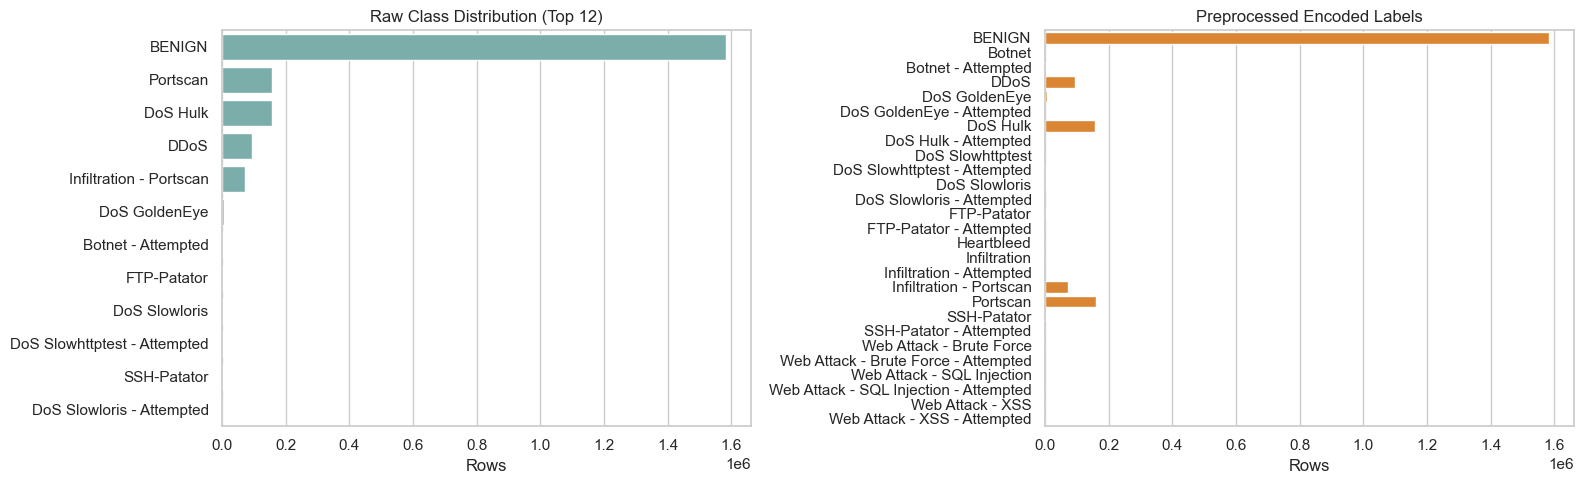

In [7]:
raw_counts = raw_df["Label"].value_counts().rename_axis("Label").reset_index(name="Count")
encoded_counts = pre_df["Label"].value_counts().sort_index().rename_axis("Encoded label").reset_index(name="Count")
encoded_counts["Original label"] = encoded_counts["Encoded label"].map(lambda i: label_encoder.classes_[int(i)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=raw_counts.head(12), y="Label", x="Count", ax=axes[0], color="#72B7B2")
axes[0].set_title("Raw Class Distribution (Top 12)")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("")

sns.barplot(data=encoded_counts, y="Original label", x="Count", ax=axes[1], color="#F58518")
axes[1].set_title("Preprocessed Encoded Labels")
axes[1].set_xlabel("Rows")
axes[1].set_ylabel("")
plt.tight_layout()

display(encoded_counts)

## 4. Missing and Infinite Values

CIC-IDS2017 contains infinite values in numeric flow features. The pipeline replaces them with NaN and then imputes using the median, which is robust for skewed network traffic.

After imputation: NaN cells = 0, Inf cells = 0


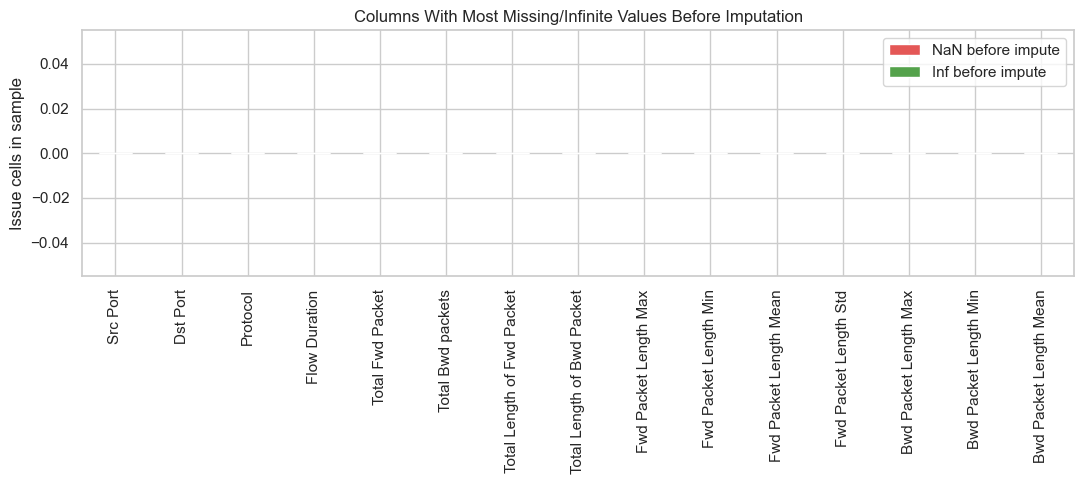

In [8]:
numeric_raw = after_drop.select_dtypes(include=[np.number])
raw_nan = numeric_raw.isna().sum()
raw_inf = pd.Series(np.isinf(numeric_raw).sum(axis=0), index=numeric_raw.columns)
quality = pd.DataFrame({"NaN before impute": raw_nan, "Inf before impute": raw_inf})
quality["Total issue cells"] = quality.sum(axis=1)
quality = quality.sort_values("Total issue cells", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
quality[["NaN before impute", "Inf before impute"]].plot(kind="bar", stacked=True, ax=ax, color=["#E45756", "#54A24B"])
ax.set_title("Columns With Most Missing/Infinite Values Before Imputation")
ax.set_ylabel("Issue cells in sample")
ax.set_xlabel("")
plt.tight_layout()

print(f"After imputation: NaN cells = {after_impute.isna().sum().sum():,}, Inf cells = {numeric_inf_count(after_impute):,}")

## 5. Feature Selection and Scaling

The saved preprocessed parquet is unscaled. The pipeline splits train/test first, fits `StandardScaler` on training only, then transforms train and test. This avoids data leakage.

,Feature,Train mean learned by scaler,Train scale learned by scaler
0,Src Port,4.849025e+04,1.595048e+04
1,Dst Port,1.249442e+03,5.821029e+03
2,Protocol,1.122859e+01,5.502128e+00
3,Flow Duration,1.243300e+07,3.101991e+07
4,Total Fwd Packet,1.253824e+01,8.731058e+02
5,Total Length of Fwd Packet,5.692085e+02,1.126838e+04
6,Fwd Packet Length Max,2.098181e+02,4.899904e+02
7,Fwd Packet Length Min,2.123222e+01,3.501198e+01
8,Fwd Packet Length Mean,4.974329e+01,9.154822e+01
9,Fwd Packet Length Std,6.056340e+01,1.546920e+02


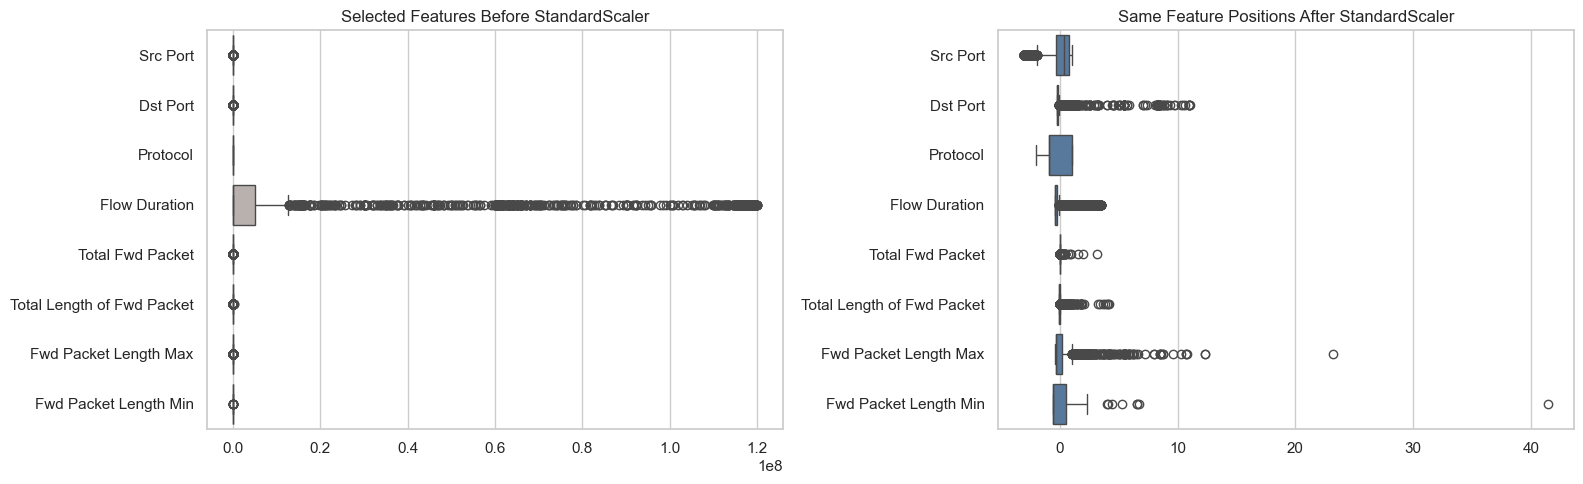

In [9]:
plot_features = feature_cols[: min(8, len(feature_cols))]
pre_sample = pre_df[plot_features].sample(min(5000, len(pre_df)), random_state=42)
scaled_sample = pd.DataFrame(X_test[: min(5000, len(X_test)), : len(plot_features)], columns=plot_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=pre_sample, orient="h", ax=axes[0], color="#BAB0AC")
axes[0].set_title("Selected Features Before StandardScaler")
sns.boxplot(data=scaled_sample, orient="h", ax=axes[1], color="#4C78A8")
axes[1].set_title("Same Feature Positions After StandardScaler")
plt.tight_layout()

scaler_table = pd.DataFrame({"Feature": feature_cols, "Train mean learned by scaler": scaler.mean_, "Train scale learned by scaler": scaler.scale_})
display(scaler_table.head(12))

## 6. Correlation Pruning Effect

The correlation filter keeps one feature from groups that carry almost duplicate information. That reduces model size for edge devices.

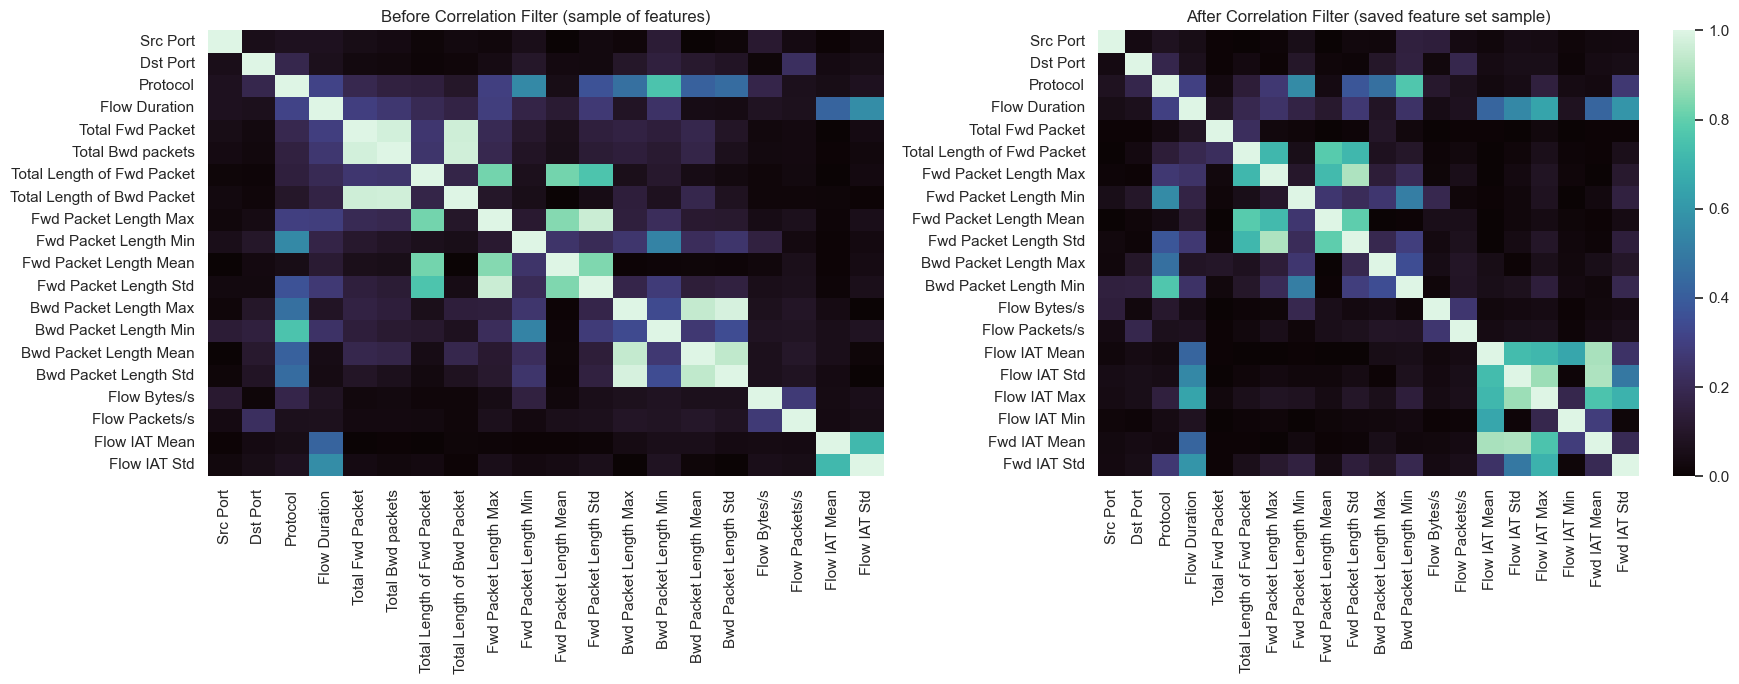

In [10]:
before_corr_features = var_features[: min(20, len(var_features))]
after_corr_features = feature_cols[: min(20, len(feature_cols))]
before_corr_df = after_impute[before_corr_features].sample(min(4000, len(after_impute)), random_state=42)
after_corr_df = pre_df[after_corr_features].sample(min(4000, len(pre_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(before_corr_df.corr().abs(), cmap="mako", vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Before Correlation Filter (sample of features)")
sns.heatmap(after_corr_df.corr().abs(), cmap="mako", vmin=0, vmax=1, ax=axes[1], cbar=True)
axes[1].set_title("After Correlation Filter (saved feature set sample)")
plt.tight_layout()

## 7. Non-IID Client Partitions

The final training set is split across clients using Dirichlet Non-IID partitioning. This heatmap shows that clients have different traffic mixtures, which is realistic for IoT gateways.

,Clients,Total training rows in shards,Smallest client rows,Largest client rows,Empty clients
0,50,1679976,3304,213521,0


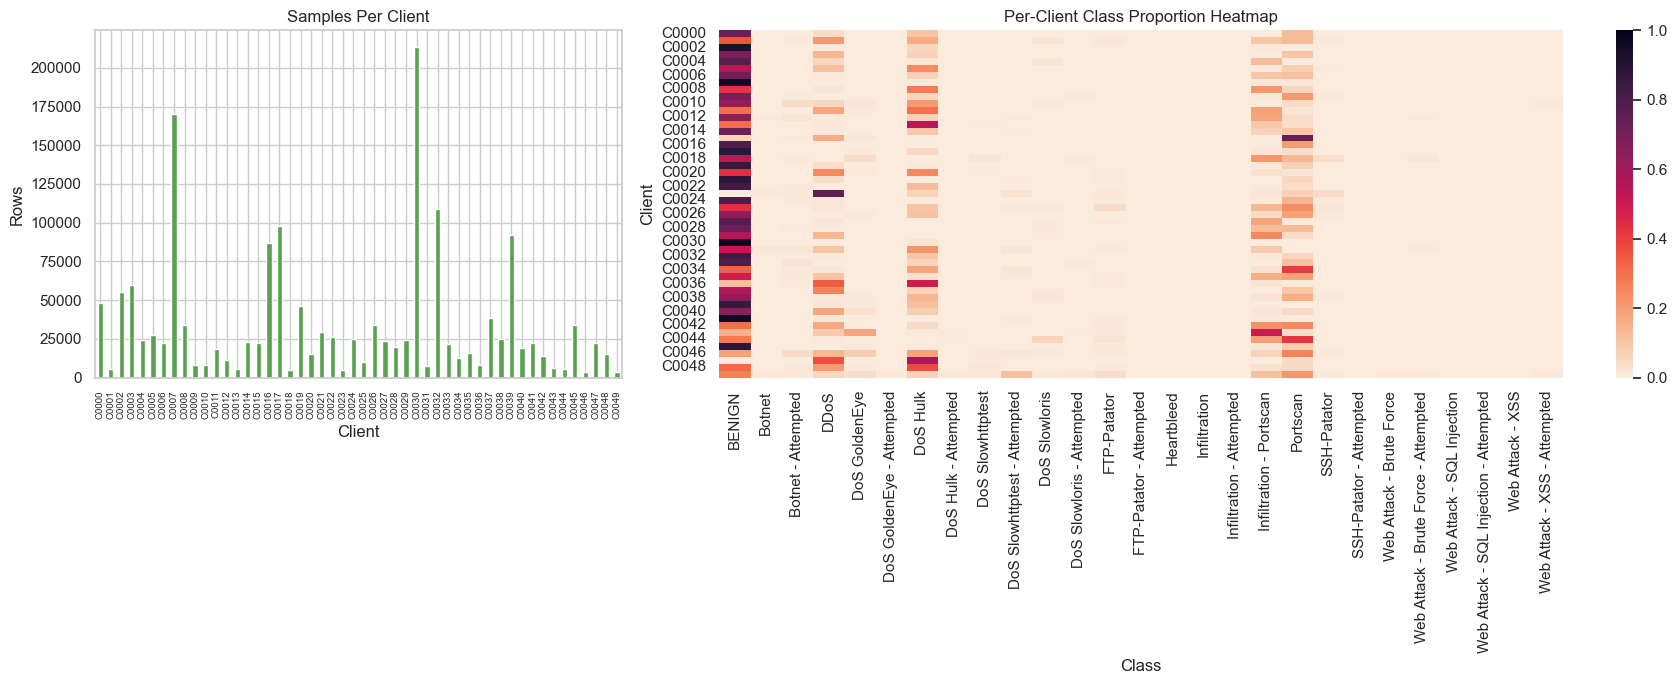

In [11]:
client_files = sorted(DATA_DIR.glob("client_*.npz"))
if not client_files:
    raise FileNotFoundError(f"No client_*.npz files found in {DATA_DIR}")

num_classes = len(label_encoder.classes_)
client_counts = []
for file in client_files:
    data = np.load(file)
    counts = np.bincount(data["y"].astype(int), minlength=num_classes)
    client_counts.append(counts)

client_counts = pd.DataFrame(client_counts, columns=label_encoder.classes_)
client_counts.index = [p.stem.replace("client_", "C") for p in client_files]
client_props = client_counts.div(client_counts.sum(axis=1).replace(0, np.nan), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1, 2]})
client_counts.sum(axis=1).plot(kind="bar", ax=axes[0], color="#59A14F")
axes[0].set_title("Samples Per Client")
axes[0].set_xlabel("Client")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", labelsize=7)

sns.heatmap(client_props, cmap="rocket_r", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Per-Client Class Proportion Heatmap")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Client")
plt.tight_layout()

partition_summary = pd.DataFrame({
    "Clients": [len(client_files)],
    "Total training rows in shards": [int(client_counts.sum().sum())],
    "Smallest client rows": [int(client_counts.sum(axis=1).min())],
    "Largest client rows": [int(client_counts.sum(axis=1).max())],
    "Empty clients": [int((client_counts.sum(axis=1) == 0).sum())],
})
display(partition_summary)

## Teacher Talking Points

- Raw CIC-IDS2017 is cleaned without using model labels for feature selection.
- Infinite and missing values are repaired before filtering.
- Constant and highly correlated features are removed to keep the MLP lightweight.
- Labels are encoded after feature cleanup so every downstream component uses stable integer IDs.
- StandardScaler is fit only on the training split, which prevents leakage from the test set.
- Client shards are intentionally Non-IID to simulate heterogeneous IoT gateways.